# VGG19

Publikacje:
 - https://www.robots.ox.ac.uk/~vgg/publications/2015/Simonyan15/simonyan15.pdf
 - https://www.researchgate.net/publication/346425175_Correlated_Time-Series_in_Multi-Day-Ahead_Streamflow_Forecasting_Using_Convolutional_Networks
 - https://ieeexplore.ieee.org/abstract/document/10551185
 - https://ieeexplore.ieee.org/document/10551185
 - https://ieeexplore.ieee.org/document/11388992
 - https://arxiv.org/abs/1610.02391
 - https://www.researchgate.net/publication/371285678_Interpreting_Hyperspectral_Remote_Sensing_Image_Classification_Methods_via_Explainable_Artificial_Intelligence
 -  transfer learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, r2_score
from torch.utils.data import WeightedRandomSampler
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image



## Data preparation

(128, 128, 3)
0.22


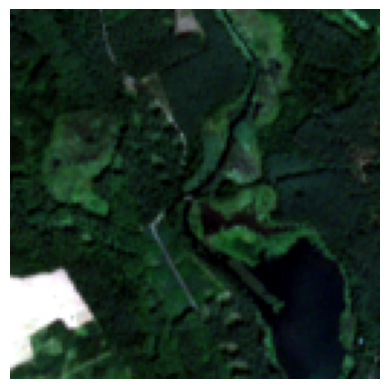

In [2]:
df = pd.read_csv('df_final.csv')
row = df.iloc[1]

chunk_id = int(row["chunk_id"])
chunk = np.load(f"images/images_chunk_{chunk_id:03d}.npy")
image = chunk[int(row['id_in_chunk'])]

rgb_image = image[:, :, 1:4]

rgb_image = rgb_image.astype('float32')
rgb_image = rgb_image / rgb_image.max() if rgb_image.max() > 0 else rgb_image
print(rgb_image.shape)
print(row['flow'])

plt.imshow(rgb_image)
plt.axis('off')
plt.show()

### Split train/test sets

In [4]:
df = pd.read_csv('df_final.csv')
df.head()

,date,flow,chunk_id,id_in_chunk
0,2015-08-10,0.09,0,343
1,2015-08-10,0.22,3,318
2,2015-08-17,0.22,3,317
3,2015-11-25,1.12,1,364
4,2015-08-04,1.43,3,448


In [6]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df = df.sort_values('date').reset_index(drop=True)

train_df = df[df['year'] <= 2022].reset_index(drop=True)
val_df = df[df['year'] == 2023].reset_index(drop=True)
test_df = df[df['year'] == 2024].reset_index(drop=True)

print('Train:', len(train_df))
print('Val:', len(val_df))
print('Test:', len(test_df))

Train: 36993
Val: 7191
Test: 7328


TO DO: split data based on station_id (train based on one group of stations, tets on the other one)

In [7]:
chunk = np.load('images/images_chunk_000.npy')

print(chunk.shape)
print(chunk.dtype)
print(chunk.min(), chunk.max())

(500, 128, 128, 4)
float32
0.0 1.0


### Transform data


In [9]:
def compute_statistics(df, images_num):

    sample = df.sample(min(images_num, len(df)), random_state=42)
    chunk_cache = {}
    rgb_pixel_values = []

    for _, row in sample.iterrows():
        chunk_id = int(row['chunk_id'])
        id_in_chunk = int(row['id_in_chunk'])
        if chunk_id not in chunk_cache:
            chunk_cache[chunk_id] = np.load(f'images/images_chunk_{chunk_id:03d}.npy',
            mmap_mode = 'r')

        image = chunk_cache[chunk_id][id_in_chunk]
        rgb_image = image[:, :, 1:4].astype('float32')

        p2  = np.percentile(rgb_image, 2)
        p98 = np.percentile(rgb_image, 98)
        rgb_image = np.clip(rgb_image, p2, p98)
        img = (rgb_image - p2) / (p98 - p2 + 1e-8)

        rgb_pixel_values.append(img.reshape(-1, 3))

    pixels = np.concatenate(rgb_pixel_values, axis=0)
    mean   = pixels.mean(axis=0).tolist()
    std    = pixels.std(axis=0).tolist()
    print(f'Mean = {mean}')
    print(f'std  = {std}')
    return mean, std

MEAN, STD = compute_statistics(train_df, 5000)

Mean = [0.20479999482631683, 0.20479999482631683, 0.20479999482631683]
std  = [0.241977721452713, 0.25372961163520813, 0.23231695592403412]


In [10]:
# MEAN = [0.485, 0.456, 0.406] # Data ImageNet
# STD  = [0.229, 0.224, 0.225]

vgg19_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(
        mean=MEAN,
        std=STD
    )
])

In [11]:
def transform_images(image):
    rgb_image = image[:, :, 1:4]
    rgb_image = rgb_image.astype('float32')
     
    p2  = np.percentile(rgb_image, 2)
    p98 = np.percentile(rgb_image, 98)
    rgb_image = np.clip(rgb_image, p2, p98)
    rgb_image = (rgb_image - p2) / (p98 - p2 + 1e-8) 
    
    x = np.transpose(rgb_image, (2, 0, 1))
    x = torch.tensor(x, dtype=torch.float32)
    x = vgg19_transform(x)
    return x

In [12]:
row = df.iloc[0]
chunk_id = int(row['chunk_id'])
id_in_chunk = int(row['id_in_chunk'])
    
chunk = np.load(f'images/images_chunk_{chunk_id:03d}.npy')
x = transform_images(chunk[0])
print(x.shape)

torch.Size([3, 224, 224])


In [13]:
class RiverFlowDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self._chunk_cache = {}
    
    def __len__(self):
        return len(self.df)
    
    def load_chunk(self, chunk_id):
        if chunk_id not in self._chunk_cache:
            self._chunk_cache[chunk_id] = np.load(
                f'images/images_chunk_{chunk_id:03d}.npy',
                mmap_mode='r'
            )
        return self._chunk_cache[chunk_id]

    def __getitem__(self, idx):
        df_row = self.df.iloc[idx]
        chunk_id = int(df_row['chunk_id'])
        id_in_chunk = int(df_row['id_in_chunk'])

        chunk = self.load_chunk(chunk_id)
        image = chunk[id_in_chunk]

        x = transform_images(image)
        y = torch.tensor(np.log1p(df_row['flow']), dtype=torch.float32)
        return x, y
    

In [14]:
bins = [0, 50, 200, 500, 10000]
labels = pd.cut(train_df['flow'], bins=bins, labels=False, include_lowest=True)
print(labels.value_counts().sort_index())

class_counts = labels.value_counts()
weights = labels.map(lambda x: 1.0 / np.sqrt(class_counts[x]))
weights = torch.tensor(weights.values, dtype=torch.float)

sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


flow
0    33730
1     2046
2      610
3      607
Name: count, dtype: int64


In [15]:
train_loader = DataLoader(RiverFlowDataset(train_df), batch_size=32, sampler=sampler,  num_workers=0)
val_loader   = DataLoader(RiverFlowDataset(val_df),   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(RiverFlowDataset(test_df),  batch_size=32, shuffle=False, num_workers=0)

## Model

In [16]:
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vgg19 = models.vgg19(weights='IMAGENET1K_V1')

True


In [17]:
for param in vgg19.features.parameters(): #zamrozenie
        param.requires_grad = False

vgg19.classifier[6] = nn.Linear(4096, 1)
model = vgg19.to(device)

In [18]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4, 
                       weight_decay=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)
num_epochs = 20
losses=[]
val_losses=[]
best_val_loss = float('inf')
patience = 5
epochs_without_improve = 0

In [ ]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_id, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        prediction = model(x).squeeze(1)
        loss = criterion(prediction, y)

        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
        if batch_id % 100 == 0:
            print(f"batch {batch_id}/{len(train_loader)}, loss: {loss.item():.4f}")

    train_loss /= len(train_loader.dataset)
    losses.append(train_loss)

    

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            val_prediction = model(x).squeeze(1)
            loss = criterion(val_prediction, y)
            val_loss += loss.item() * x.size(0)
        
        val_loss /=len(val_loader.dataset)
        val_losses.append(val_loss)
    scheduler.step(val_loss)
    print(f'Epoch {epoch+1:02d}')
    print(f'Train_loss: {train_loss:.4f}')
    print(f'Val_loss: {val_loss:.4f}')

    if val_loss > best_val_loss:
        epochs_without_improve += 1
        print(f'No improvement - {epochs_without_improve}/{patience}')
        if epochs_without_improve >= patience:
            print('Early stopping.')
            break
    else:
        best_val_loss= val_loss
        epochs_without_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')

batch 0/1157, loss: 8.4349
batch 100/1157, loss: 1.5592
batch 200/1157, loss: 0.6585
batch 300/1157, loss: 1.2953
batch 400/1157, loss: 0.6351
batch 500/1157, loss: 0.6327
batch 600/1157, loss: 0.8665
batch 700/1157, loss: 0.5117
batch 800/1157, loss: 0.4567
batch 900/1157, loss: 0.4493
batch 1000/1157, loss: 0.4939
batch 1100/1157, loss: 0.3637
Epoch 01
Train_loss: 0.7773
Val_loss: 0.3900
batch 0/1157, loss: 0.5909
batch 100/1157, loss: 0.4006
batch 200/1157, loss: 0.5588
batch 300/1157, loss: 0.2470
batch 400/1157, loss: 0.2022
batch 500/1157, loss: 0.4044
batch 600/1157, loss: 0.3390
batch 700/1157, loss: 0.3875
batch 800/1157, loss: 0.4764
batch 900/1157, loss: 0.2819
batch 1000/1157, loss: 0.3480
batch 1100/1157, loss: 0.2274
Epoch 02
Train_loss: 0.3966
Val_loss: 0.3332
batch 0/1157, loss: 0.3662
batch 100/1157, loss: 0.2672
batch 200/1157, loss: 0.3129
batch 300/1157, loss: 0.3029
batch 400/1157, loss: 0.4800
batch 500/1157, loss: 0.2940
batch 600/1157, loss: 0.2566
batch 700/115

In [19]:
model.load_state_dict(torch.load('best_model.pth'))

<All keys matched successfully>

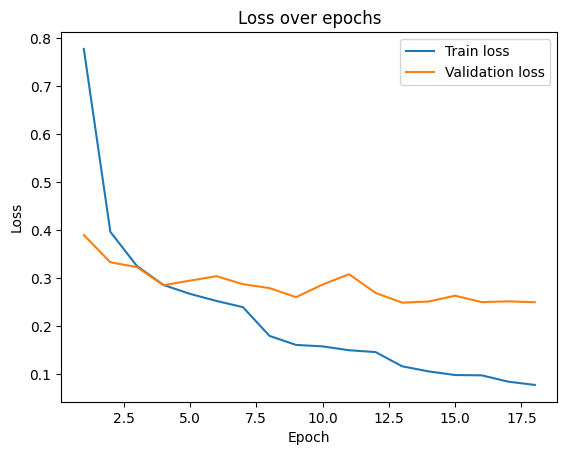

In [ ]:
epochs = range(1, len(losses) + 1)
plt.plot(epochs, losses, label='Train loss')
plt.plot(epochs, val_losses, label='Validation loss')

plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluation

In [22]:
model.eval()

pred_y =[]
true_y =[]

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        prediction = model(x).squeeze(1)
        
        pred_y.append(prediction.cpu().numpy())
        true_y.append(y.cpu().numpy())

all_preds =  np.concatenate(pred_y)
all_trues = np.concatenate(true_y)

all_true_y   = np.expm1(all_trues)
all_pred_y = np.expm1(all_preds)
   
mae = mean_absolute_error(all_true_y, all_pred_y)
rmse = np.sqrt(np.mean((all_true_y - all_pred_y) ** 2))
r2 = r2_score(all_true_y, all_pred_y)

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

MAE: 14.7847
RMSE: 78.3442
R2: 0.6727


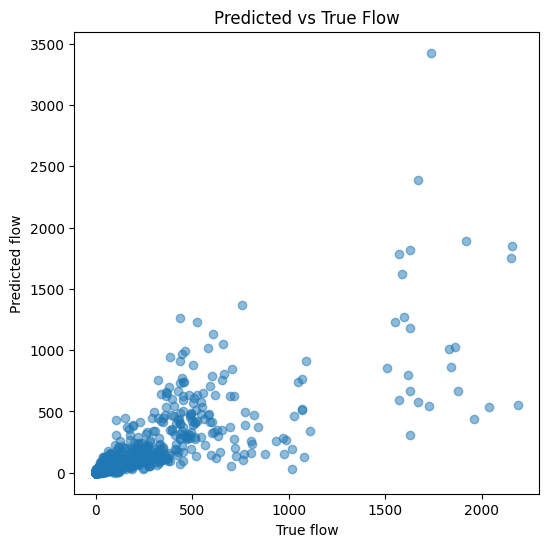

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(all_true_y, all_pred_y, alpha=0.5)
plt.title('Predicted vs True Flow')
plt.xlabel('True flow')
plt.ylabel('Predicted flow')
plt.show()

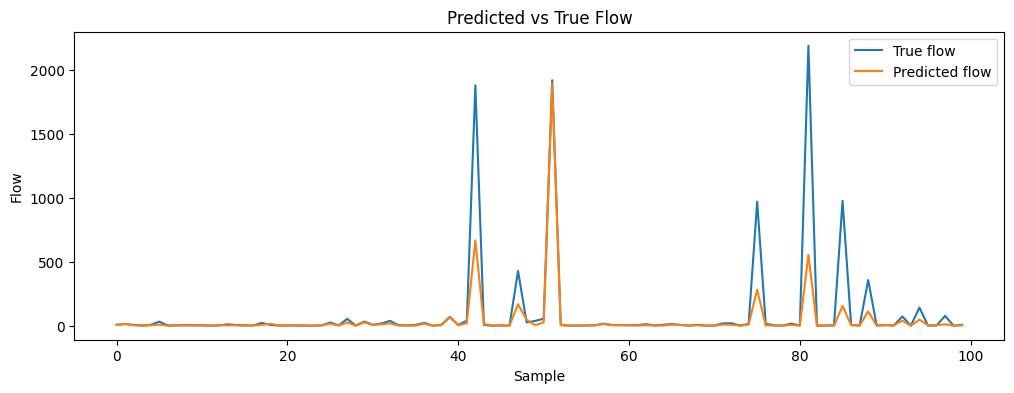

In [24]:
n = 100  
plt.figure(figsize=(12, 4))
plt.plot(all_true_y[:n], label='True flow')
plt.plot(all_pred_y[:n], label='Predicted flow')
plt.xlabel('Sample')
plt.ylabel('Flow')
plt.title('Predicted vs True Flow')
plt.legend()
plt.show()

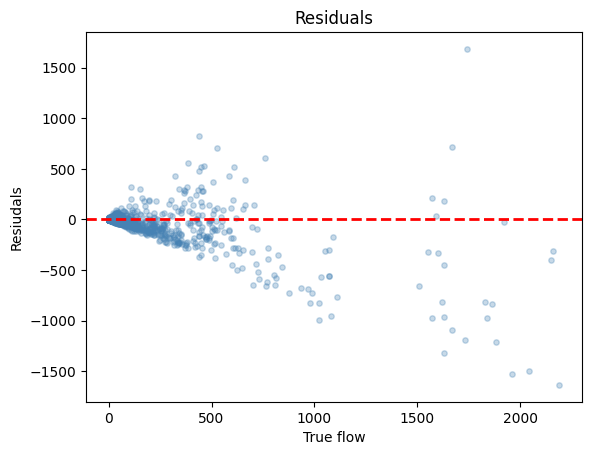

In [25]:
residuals = all_pred_y - all_true_y
plt.scatter(all_true_y, residuals, alpha=0.3, s=15, color='steelblue')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.title('Residuals')
plt.xlabel('True flow')
plt.ylabel('Resiudals')
plt.show()

## Features indetification

- Grad-CAM

Additional:
- Occlusion sensitivity
- Integrated Gradients

In [26]:
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

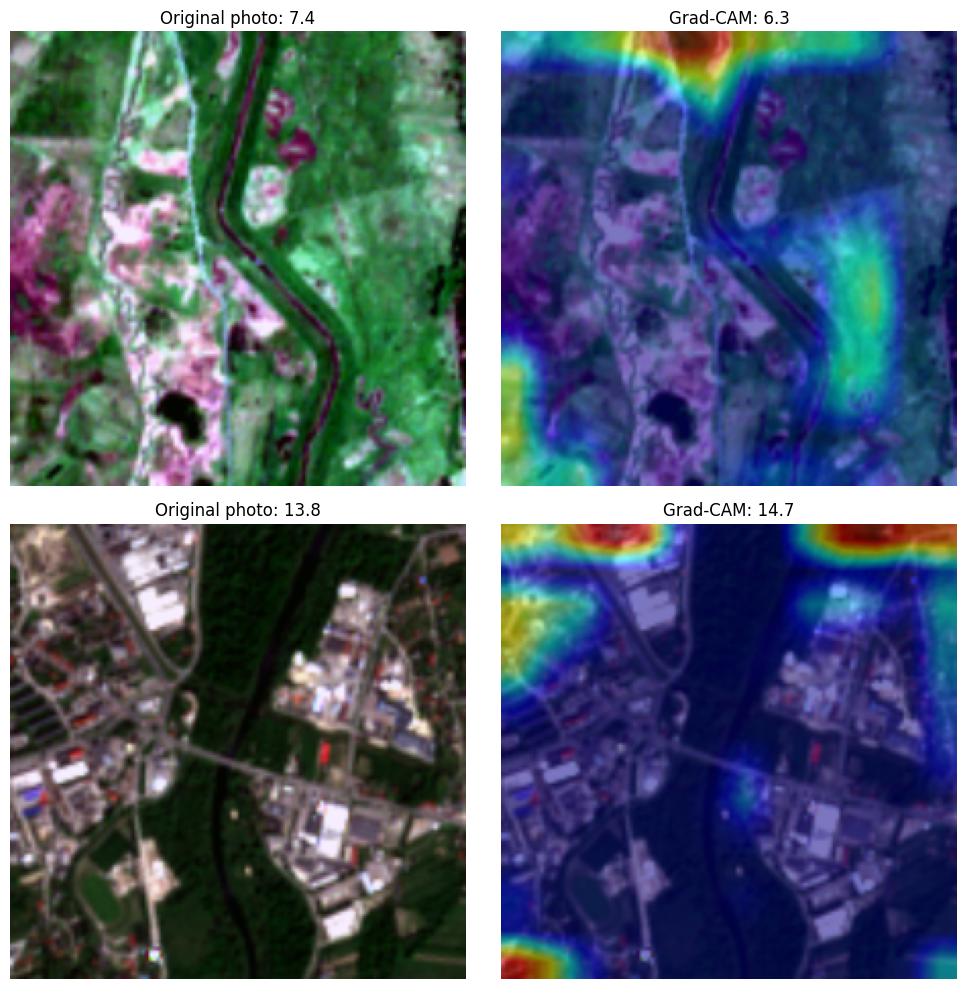

In [40]:
for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

target_layers = [model.features[34]]
cam = GradCAM(model=model, target_layers=target_layers)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i in range(2):
    y = test_df['flow'][i]
    chunk_id = int(test_df['chunk_id'][i])
    chunk = np.load(f"images/images_chunk_{chunk_id:03d}.npy")
    image = chunk[int(test_df['id_in_chunk'][i])]

    x = transform_images(image)
    img_tensor = x.unsqueeze(0).to(device).requires_grad_(True)
    grad_cam = cam(input_tensor=img_tensor)

    img = x.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    img = np.float32(img)

    heatmap_on_img = show_cam_on_image(img, grad_cam[0], use_rgb=True)
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Original photo: {y:.1f}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap_on_img)
    axes[i, 1].set_title(f'Grad-CAM: {np.expm1(model(img_tensor).item()):.1f}')
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

In [51]:
def occlusion_sensitivity(img_tensor, patch_size=32, stride=16):
    model.eval()

    with torch.no_grad():
        baseline_prediction = model(img_tensor).item()

    _, _, H, W = img_tensor.shape

    heatmap = np.zeros((H, W), dtype=np.float32)
    hidden_counts = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):

            occluded_img = img_tensor.clone()
            occluded_img[:, :, y:y+patch_size, x:x+patch_size] = 0.0

            with torch.no_grad():
                occluded_prediction = model(occluded_img).item()

            difference = baseline_prediction - occluded_prediction

            heatmap[y:y+patch_size, x:x+patch_size] += difference
            hidden_counts[y:y+patch_size, x:x+patch_size] += 1

    hidden_counts[hidden_counts == 0] = 1
    heatmap = heatmap / hidden_counts

    return heatmap, baseline_prediction


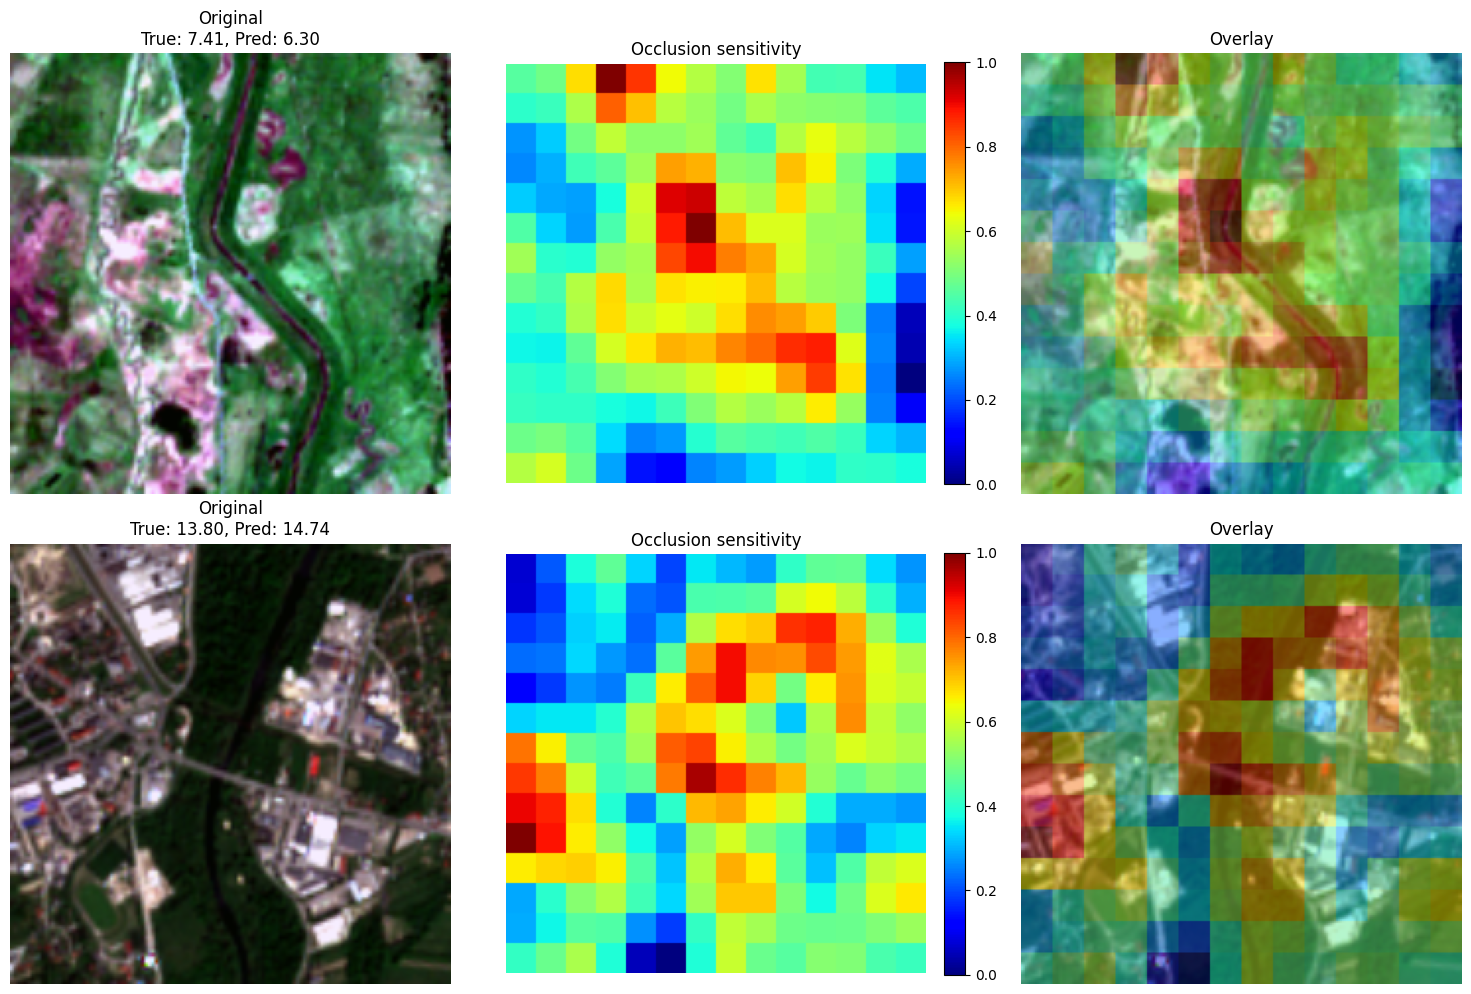

In [ ]:
indices = [0, 1]  

fig, axes = plt.subplots(len(indices), 3, figsize=(15, 5 * len(indices)))

for row_idx, idx in enumerate(indices):
    row = test_df.iloc[idx]
    true_flow = row["flow"]
    chunk_id = int(row["chunk_id"])
    id_in_chunk = int(row["id_in_chunk"])

    chunk = np.load(f"images/images_chunk_{chunk_id:03d}.npy", mmap_mode="r")
    image = chunk[id_in_chunk]

    x = transform_images(image)
    img_tensor = x.unsqueeze(0).to(device)

    heatmap, original_pred_log = occlusion_sensitivity(
        img_tensor, patch_size=32, stride=16
    )

    pred_flow = np.expm1(original_pred_log)

    img = x.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = np.float32(img)

    heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_title(f"Original\nTrue: {true_flow:.2f}, Pred: {pred_flow:.2f}")
    axes[row_idx, 0].axis("off")

    # Heatmap
    im = axes[row_idx, 1].imshow(heatmap_norm, cmap="jet")
    axes[row_idx, 1].set_title("Occlusion sensitivity")
    axes[row_idx, 1].axis("off")
    plt.colorbar(im, ax=axes[row_idx, 1], fraction=0.046, pad=0.04)

    # Overlay
    axes[row_idx, 2].imshow(img)
    axes[row_idx, 2].imshow(heatmap_norm, cmap="jet", alpha=0.45)
    axes[row_idx, 2].set_title("Overlay")
    axes[row_idx, 2].axis("off")

plt.tight_layout()
plt.savefig("occlusion.png", dpi=150, bbox_inches="tight")
plt.show()